In [2]:
# ============================================================
# Experiment: Polynomial Regression on Auto MPG Dataset
# Prediction of MPG using Engine Displacement
# ============================================================

# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
    # Load Auto MPG dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

# Display first five rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
# Select displacement as input feature
# Select mpg as target variable

X = df[['displacement']]
y = df['mpg']

# Display the selected data
print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [8]:
# Check missing values
print("Missing values in displacement:", X['displacement'].isnull().sum())
print("Missing values in mpg:", y.isnull().sum())

Missing values in displacement: 0
Missing values in mpg: 0


In [10]:
# Remove rows containing missing values
data = df[['displacement', 'mpg']].dropna()

# Separate input and output
X = data[['displacement']]
y = data['mpg']

print("Dataset shape:", data.shape)

Dataset shape: (398, 2)


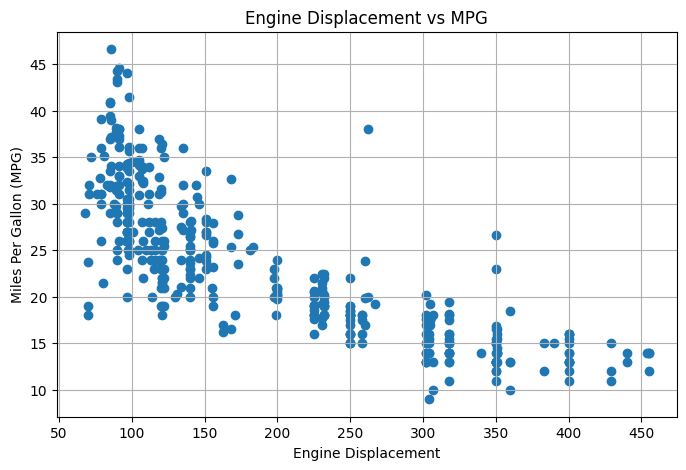

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Engine Displacement vs MPG")

plt.grid(True)
plt.show()

In [14]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 318
Testing samples: 80


In [16]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict on test data
y_pred_linear = linear_model.predict(X_test)

In [18]:
# Calculate MSE
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Calculate R-squared
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MSE:", mse_linear)
print("R-squared:", r2_linear)

Linear Regression Results
-------------------------
MSE: 18.102543998358946
R-squared: 0.6633114869465596


In [20]:
# Store results
results = []

# Add Linear Regression results
results.append({
    'Model': 'Linear Regression',
    'Degree': 1,
    'MSE': mse_linear,
    'R-squared': r2_linear
})

# Try polynomial degrees from 2 to 5
for degree in range(2, 6):

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    # Transform training and testing data
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    poly_model = LinearRegression()

    # Train polynomial regression model
    poly_model.fit(X_train_poly, y_train)

    # Make predictions
    y_pred_poly = poly_model.predict(X_test_poly)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    # Store results
    results.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse,
        'R-squared': r2
    })

In [23]:
# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230899,0.716721


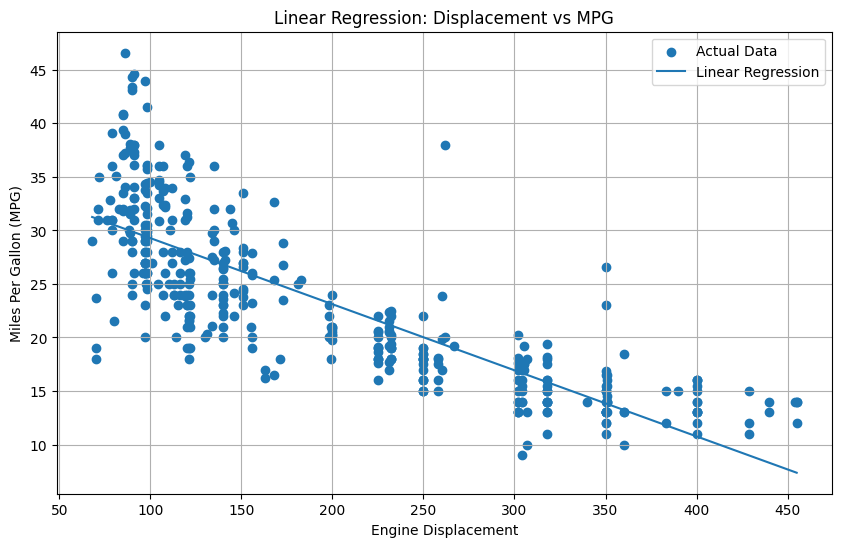

In [27]:
# Create sorted values for smooth plotting
X_plot = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

# Predict using linear model
y_plot_linear = linear_model.predict(X_plot)

# Plot original data
plt.figure(figsize=(10, 6))

plt.scatter(X, y, label="Actual Data")

# Plot linear regression line
plt.plot(
    X_plot,
    y_plot_linear,
    label="Linear Regression"
)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Linear Regression: Displacement vs MPG")

plt.legend()
plt.grid(True)

plt.show()

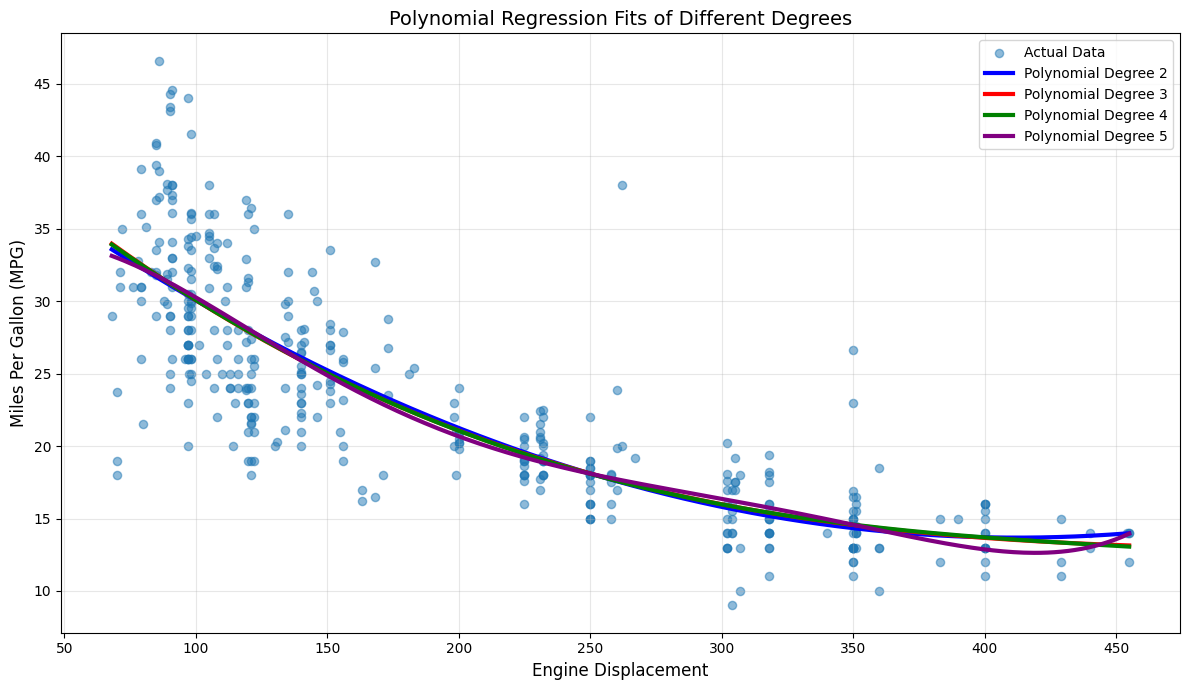

In [43]:
# Create smooth X values as a DataFrame
X_plot = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

plt.figure(figsize=(12, 7))

# Plot original data
plt.scatter(
    X['displacement'],
    y,
    label="Actual Data",
    alpha=0.5,
    s=35
)

# Contrasting colors for different polynomial degrees
colors = ['blue', 'red', 'green', 'purple']

# Plot polynomial models
for degree in range(2, 6):

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    # Transform training data
    X_train_poly = poly.fit_transform(X_train)

    # Transform plotting data
    X_plot_poly = poly.transform(X_plot)

    # Create and train model
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    # Predict
    y_plot_poly = poly_model.predict(X_plot_poly)

    # Plot polynomial curve
    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        color=colors[degree-2],
        linewidth=3,
        label=f"Polynomial Degree {degree}"
    )

plt.xlabel("Engine Displacement", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.title("Polynomial Regression Fits of Different Degrees", fontsize=14)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

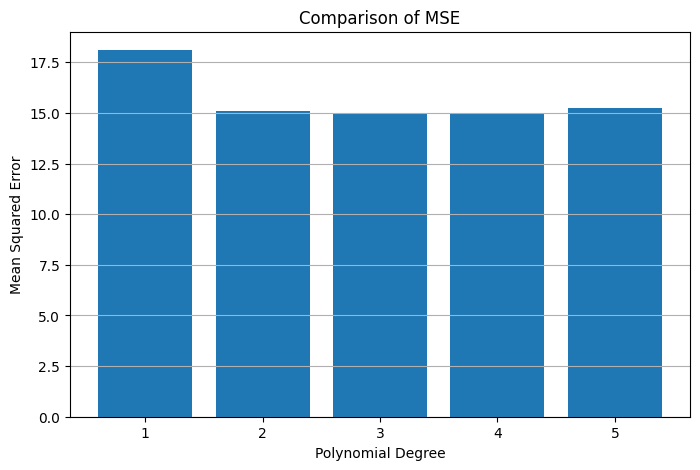

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")

plt.grid(axis='y')

plt.show()

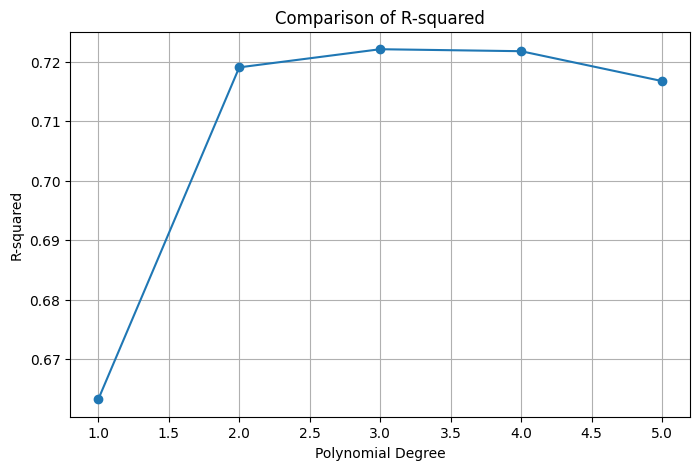

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")

plt.grid(True)

plt.show()